# Building Data Cubes: The YAML Recipe Guide

The data cubing engine is instantiated by the bmd_cube class which synthesises the outputs from the different data provider cube classes into a comprehensive data tree that groups all the datasets related to your area of interest in an easily accessible data structure called a data tree. The cubing engine itself abstracts away all complexity of API's or developing complex processing pipelines and allows the user to request data by creating a `recipe` which is a structured input that communicates with the engine backend. 

## 1. Yaml recipe template

The end user communicates with the engine through the use of a yaml recipe file that follows a structured template that the user can adjust to tailor the query to their specific needs. The complete extent of the template looks as follows and we will explain each section in this tutorial and how you can adjust it 

### Template

```
base_dir: ""
cube_name: ""

export:
  as_tree: [true/false]
  as_nested_dir: [true/false]

# ======================================================================
# 1. SPATIAL & TEMPORAL SELECTION
# ======================================================================
spatial:
  target_grid: ""
  target_resolution: ""
  use_bbox: [true/false]  
  bbox:
      long_min: 
      long_max: 
      lat_min: 
      lat_max: 

temporal:
  start_year: 
  start_month: 
  end_year: 
  end_month: 

# ======================================================================
# 2. DATA SOURCES
# ======================================================================
sources:
  # --------------------------------------------------------------------
  # WEkEO DATASETS (Copernicus Land Monitoring Service)
  # --------------------------------------------------------------------
  wekeo:
    enabled: [true/false]
    dataset_resolution: "" # Fetches the finest raw data before upscaling/downscaling
    catalog_path: ""
    
    # ------------------------------------------------------------------
    # GLOBAL DEFAULTS for WEkEO
    # If a dataset below doesn't specify an override, it inherits these.
    # ------------------------------------------------------------------
    defaults:
      continuous_aggregations: 
        - ""
      discrete_classes: "" # Instructs the engine to fetch every available class

    # ------------------------------------------------------------------
    # DATA INVENTORY (Grouped by GeoParquet 'collection' Keys)
    # ------------------------------------------------------------------
    categories:
      # --- Tree Cover & Forest (TCF) ---
      TCF:
        include: [true/false]
        datasets:
          Tree_Cover_Density:
            include: [true/false]
            type: ""
          
          Forest_Type:
            include: [true/false]
            type: ""
            # OVERRIDE: We only want specific classes
            classes:
              - ""
              
          Dominant_Leaf_Type:
            include: [true/false]
            type: ""
            
          Broadleaved_Cover_Density:
            include: [true/false]
            type: ""
            
          Coniferous_Cover_Density:
            include: [true/false]
            type: ""
            
          Forest_Additional_Support_Layer:
            include: [true/false]
            type: ""
            
          # Confidence Layers
          Tree_Cover_Density_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Dominant_Leaf_Type_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]

      # --- Grassland (GRA) ---
      GRA:
        include: [true/false]
        datasets:
          Grassland:
            include: [true/false]
            type: ""
            
          Herbaceous_Cover:
            include: [true/false]
            type: ""
            
          Ploughing_Indicator:
            include: [true/false]
            type: ""
            
          Grassland_Mowing_Events:
            include: [true/false]
            type: ""
            
          Grassland_Mowing_Dates:
            include: [true/false]
            type: ""
            
          # Confidence Layers
          Grassland_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Grassland_Mowing_Events_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]

      # --- Imperviousness (IMP) ---
      IMP:
        include: [true/false]
        datasets:
          Imperviousness_Density:
            include: [true/false]
            type: ""
            
          Impervious_Built_up:
            include: [true/false]
            type: ""
            
          Share_of_Built_up:
            include: [true/false]
            type: ""
            
          # Confidence Layers
          Confidence_layer_for_Imperviousness_Density:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Confidence_layer_for_Impervious_Built_up:
            include: [true/false]
            type: ""
            aggregations: [""]

      # --- Small Woody Features (SLF) ---
      SLF:
        include: [true/false]
        datasets:
          Small_Woody_Features:
            include: [true/false]
            type: ""
            
          Woody_Vegetation_Layer:
            include: [true/false]
            type: ""
            
          Forest_Mask:
            include: [true/false]
            type: ""
            
          Crop_Mask:
            include: [true/false]
            type: ""

      # --- Cropland (CRL) ---
      CRL:
        include: [true/false]
        datasets:
          Crop_Types:
            include: [true/false]
            type: ""
            
          Cropping_Seasons_Yearly:
            include: [true/false]
            type: ""
            
          Fallow_Land_Presence:
            include: [true/false]
            type: ""
            
          Bare_Soil_Before:
            include: [true/false]
            type: ""
            
          Bare_Soil_After:
            include: [true/false]
            type: ""
            
          Main_Crop_Emergence:
            include: [true/false]
            type: ""
            
          Main_Crop_Harvest:
            include: [true/false]
            type: ""
            
          Main_Crop_Duration:
            include: [true/false]
            type: ""
            
          Secondary_Crops_Type:
            include: [true/false]
            type: ""
            
          Secondary_Crops_Emergence:
            include: [true/false]
            type: ""
            
          Secondary_Crops_Duration:
            include: [true/false]
            type: ""
            
          # Confidence Layers
          Crop_Types_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Fallow_Land_Presence_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Bare_Soil_Before_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Bare_Soil_After_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Main_Crop_Emergence_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Main_Crop_Harvest_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Main_Crop_Duration_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]
            
          Secondary_Crops_Duration_Confidence_Layer:
            include: [true/false]
            type: ""
            aggregations: [""]

      # --- CORINE Land Cover ---
      CORINE:
        include: [true/false]
        datasets:
          Corine_Land_Cover_2018:
            include: [true/false]
            type: ""
            
          Corine_Land_Cover_2012:
            include: [true/false]
            type: ""
            
          Corine_Land_Cover_2006:
            include: [true/false]
            type: ""
            
          Corine_Land_Cover_2000:
            include: [true/false]
            type: ""
            
          Corine_Land_Cover_1990:
            include: [true/false]
            type: ""

  # --------------------------------------------------------------------
  # CHELSA DATASETS (High-Resolution Climatologies)
  # --------------------------------------------------------------------
  chelsa:
    enabled: [true/false]
    catalog_path: ""
    levels: 
      # --- DAILY TIME SERIES (Inherits global 'temporal' block) ---
      daily:
        include: [true/false]
        variables:
          tas: [true/false]     # Mean daily air temperature
          tasmax: [true/false]  # Maximum daily air temperature
          tasmin: [true/false]  # Minimum daily air temperature
          pr: [true/false]      # Daily precipitation amount
          clt: [true/false]     # Cloud area fraction
          rsds: [true/false]    # Surface downwelling shortwave radiation
          sfcWind: [true/false] # Near-surface wind speed
          hurs: [true/false]    # Near-surface relative humidity
          vpd: [true/false]     # Vapor pressure deficit

      # --- MONTHLY TIME SERIES (Inherits global 'temporal' block) ---
      monthly:
        include: [true/false]
        variables:
          tas: [true/false]
          tasmax: [true/false]
          tasmin: [true/false]
          pr: [true/false]
          clt: [true/false]
          rsds: [true/false]
          sfcWind: [true/false]
          hurs: [true/false]
          vpd: [true/false]

      # --- ANNUAL TIME SERIES (Inherits global 'temporal' block) ---
      annual:
        include: [true/false]
        variables:
          tas: [true/false]
          tasmax: [true/false]
          tasmin: [true/false]
          pr: [true/false]

      # --- CLIMATOLOGIES (30-year normals, Overrides global 'temporal' block) ---
      climatologies:
        include: [true/false]
        
        # Select Base Periods / Projection Horizons
        time_ranges:
          "1981-2010": [true/false]  # Historical observation baseline
          "2011-2040": [true/false]  # Near-term future
          "2041-2070": [true/false]  # Mid-term future
          "2071-2100": [true/false]  # Long-term future
        
        # Select Climate Models (CMIP6 Ensembles)
        ensembles:
          historical: [true/false]   # REQUIRED if "1981-2010" is true
          GFDL-ESM4: [true/false]
          IPSL-CM6A-LR: [true/false]
          MPI
```

### 1. Global export settings

The top of the recipe defines where and how your data is saved:

* **`base_dir`**: The root directory where your cube will be generated.
* **`cube_name`**: The name of the final file or folder.
* **`export`**: Controls the file format of the output.
    * **`as_tree: true`**: Packages everything into one single `.nc` (NetCDF) file. This exports the generated cubes as a structured datatree object (more explaination later in the tutorial on the datatree concept)
    * **`as_nested_dir: true`**: Saves individual datasets into an organized folder hierarchy, which is highly recommended for very large cubes.

### 2. Spatial Configuration: Grids & Bounding Boxes

The `spatial` block is the physical foundation of your data cube. The engine uses a strict internal `GRID_REGISTRY` to ensure all datasets—no matter their original resolution or projection—snap perfectly to the same pixels.

#### Choosing your `target_grid` and `target_resolution`
You must select a base coordinate system and a resolution. The engine supports the following combinations:

* **`"EEA"` (European Environment Agency - EPSG:3035)**: Ideal for European metric analyses.
    * *Supported resolutions:* `"100m"`, `"250m"`, `"500m"`, `"1km"`, `"10km"`.
* **`"Global_EqualArea"` (EPSG:6933)**: Ideal for global volumetric or area-based studies.
    * *Supported resolutions:* `"100m"`, `"250m"`, `"500m"`, `"1km"`, `"10km"`.
* **`"Global_WGS84"` (EPSG:4326)**: Standard geographic degrees.
    * *Supported resolutions:* `"3sec"` (~100m), `"7_5sec"` (~250m), `"15sec"` (~500m), `"30sec"` (~1km), `"5min"` (~10km).

#### Defining your `bbox`
If `use_bbox` is set to `true`, the engine will crop the global datasets to your specific region of interest. Always provide these coordinates in standard **WGS84 decimal degrees** (`long_min`, `long_max`, `lat_min`, `lat_max`), regardless of what `target_grid` you selected. The engine handles the complex spatial reprojection math automatically.


### 3. Temporal Configuration

The `temporal` block establishes the default global timeline for continuous datasets, like daily temperature or yearly land cover.

* **Time Bounds**: Specify the `start_year`, `start_month`, `end_year`, and `end_month`.
* **Exceptions**: Certain datasets, like 30-year climatologies, ignore this block and use their own specific `time_ranges` settings defined directly within the `sources` block.

### 4. Data Sources & Catalogs

The `sources` block contains the actual scientific layers you want to extract.

#### The `catalog_path` (Crucial Step)
To fetch data without downloading terabytes of unnecessary files, the engine queries a localized database. These databases are stored as highly optimized GeoParquet files (`.parquet`).

* **Local Pointer**: You must provide the `catalog_path` pointing to these files on your local machine.
* **Repository Defaults**: In the repository, these catalogs are standardly stored in the `meta/` directory (e.g., `meta/chelsa_gp_stac/chelsa_master.parquet`). **Always use absolute paths** to completely avoid execution or escape sequence errors.

#### Selecting Variables
Under each enabled source, datasets are grouped logically (e.g., CHELSA is grouped by levels like `daily` or `bioclim`).

1. Ensure the parent group is set to `include: true`.
2. Set the specific variables you want to `true` (e.g., `tas: true` for temperature).
3. Everything else can be set to `false` or completely deleted from the YAML file to save space.

## 2. Building an example datacube 

As an example to illustrate how to utilize the cubing engine we will generate a data cube that takes information from the greater German area 

<p align="center">
  <img src="img/aoi_2.png" alt="Area of Interest" width="50%">
</p>

For this extraction, we define a strict bounding box `(5.40, 47.20, 15.17, 54.81)` and configure the engine to pull a diverse array of structural layers from the CHELSA dataset. The request bridges both high-frequency observational data and long-term macro-climatic models by extracting the following components:

* **Daily, Monthly, and Annual Series:** Continuous matrices representing mean air temperature (`tas`) and vapor pressure deficit (`vpd`) for the specific temporal bounds of the year 2018.
* **30-Year Climatologies:** Long-term climatic averages for temperature (`tas`) and precipitation (`pr`). We are requesting both the historical baseline (1981–2010) and a near-term future horizon (2011–2040) modeled under the optimistic `ssp126` emission scenario using the `GFDL-ESM4` ensemble.
* **Bioclimatic Indicators:** Specialized eco-meteorological metrics—specifically Annual Mean Temperature (`bio01`) and Annual Precipitation (`bio12`)—evaluated across the same historical and future projection frameworks.

The data will be transformed to an EEA grid with 10km grid cells

In [2]:
import yaml

german_recipe = """
base_dir: "./cubing_output/"
cube_name: "german_chelsa_cube"

export:
  as_tree: true
  as_nested_dir: true 

# ======================================================================
# 1. SPATIAL & TEMPORAL SELECTION
# ======================================================================
spatial:
  target_grid: "EEA"
  target_resolution: "10km"
  use_bbox: true  
  bbox:
      long_min: 5.4
      long_max: 15.178570
      lat_min: 47.207754
      lat_max: 54.814383

temporal:
  start_year: 2018
  start_month: 1
  end_year: 2018
  end_month: 12

# ======================================================================
# 2. DATA SOURCES
# ======================================================================
sources:
  # --------------------------------------------------------------------
  # CHELSA DATASETS (High-Resolution Climatologies)
  # --------------------------------------------------------------------
  chelsa:
    enabled: true
    catalog_path:  "C:/Users/niels/Documents/Repositories/BmC/meta/chelsa_gp_stac/chelsa_master.parquet"
    levels: 
      # --- DAILY TIME SERIES (Inherits global 'temporal' block) ---
      daily:
        include: true
        variables:
          tas: true     # Mean daily air temperature

      # --- MONTHLY TIME SERIES (Inherits global 'temporal' block) ---
      monthly:
        include: true
        variables:
          tas: true
          vpd: true

      # --- ANNUAL TIME SERIES (Inherits global 'temporal' block) ---
      annual:
        include: true
        variables:
          tas: true

      # --- CLIMATOLOGIES (30-year normals, Overrides global 'temporal' block) ---
      climatologies:
        include: true
        
        # Select Base Periods / Projection Horizons
        time_ranges:
          "1981-2010": true  # Historical observation baseline
          "2011-2040": true # Near-term future
        
        # Select Climate Models (CMIP6 Ensembles)
        ensembles:
          historical: true   # REQUIRED if "1981-2010" is true
          GFDL-ESM4: true
        
        # Select Emission Scenarios (SSPs)
        scenarios:
          historical: true   # REQUIRED if "1981-2010" is true
          ssp126: true      # Highly optimistic / Strong mitigation

          
        # Select Climatological Variables (Long-term averages of core variables)
        variables:
          tas: true     # Mean air temperature
          pr: true      # Precipitation amount


      # --- BIOCLIMATIC VARIABLES (Overrides global 'temporal' block) ---
      bioclim:
        include: true  
        # Select Base Periods / Projection Horizons
        time_ranges:
          "1981-2010": true  # Historical observation baseline
          "2011-2040": true  # Near-term future
        
        # Select Climate Models (CMIP6 Ensembles)
        ensembles:
          historical: true   # REQUIRED if "1981-2010" is true
          GFDL-ESM4: true
        
        # Select Emission Scenarios (SSPs)
        scenarios:
          historical: true   # REQUIRED if "1981-2010" is true
          ssp126: true       # Highly optimistic / Strong mitigation
          
        # --------------------------------------------------------------
        # EXHAUSTIVE BIOCLIMATIC VARIABLES (CHELSA V2.1)
        # Set to 'true' to include, 'false' or delete the line to exclude
        # --------------------------------------------------------------
        variables:
          # --- Standard Temperature & Precipitation (Bio01 - Bio19) ---
          bio01: true   # Annual Mean Temperature
          bio12: true   # Annual Precipitation
"""
try:
    recipe_data = yaml.safe_load(german_recipe)
    
    with open("german_clim_recipe.yaml", "w", encoding="utf-8") as file:
        yaml.dump(recipe_data, file, default_flow_style=False, sort_keys=False)
        
    print("YAML file successfully generated!")
    
except yaml.YAMLError as exc:
    print(exc)

YAML file successfully generated!


Now that we have generated a yaml recipe that satisfies our needs we can feed it to the cubing engine

In [3]:
from bmc.cube.bmd import bmd_cube

bmd_engine = bmd_cube()
bmd_engine.generate_bmd_data("german_clim_recipe.yaml", "")

Notice: Destination directory './cubing_output/' not found. Creating path...
Initializing CHELSA cube generation...


All information has been logged to the log file stored in the base_dir folder you specified in the recipe. After gather the data it needs to be constructed into a datatree and then exported

In [4]:
bmd_engine.construct_datatree("german_clim_recipe.yaml", "")
bmd_engine.export_tree("german_clim_recipe.yaml", "")

Exported DataTree to single file: ./cubing_output/german_chelsa_cube.nc
Exported DataTree to nested directory: ./cubing_output/german_chelsa_cube


After constructing and exporting the data tree the user can immediately use the end product by either calling the `.data_tree` of the engine or they can use the `import_tree` function to either import the single tree file or the nested directory

In [9]:
bmd_engine.data_tree
german_cube = bmd_engine.import_tree("./cubing_output/german_chelsa_cube.nc")

Imported DataTree from single file: ./cubing_output/german_chelsa_cube.nc


In [10]:
german_cube

<xarray.DataTree>
Group: /
└── Group: /chelsa
    ├── Group: /chelsa/daily
    │       Dimensions:      (time: 362, y: 87, x: 75)
    │       Coordinates:
    │         * x            (x) float64 600B 3.975e+06 3.985e+06 ... 4.705e+06 4.715e+06
    │         * y            (y) float64 696B 3.535e+06 3.525e+06 ... 2.685e+06 2.675e+06
    │         * time         (time) int64 3kB 1514764800000000000 ... 1545955200000000000
    │       Data variables:
    │           tas          (time, y, x) float64 19MB ...
    │           spatial_ref  int64 8B ...
    │       Attributes: (12/27)
    │           forcing:             ERA5
    │           version:             2.1
    │           long_name:           tas
    │           add_offset:          0.0
    │           note:                -
    │           _FillValue:          0
    │           ...                  ...
    │           cf_standard_name:    air_temperature
    │           source_id:           CHELSA_V2.1
    │           data_cite:           Karger D.N., Conrad, O., Böhner, J., Kawohl, T., Kre...
    │           experiment_id:       observation
    │           variable_long_name:  Daily Mean Near-Surface Air Temperature
    │           citation1:           Karger, D.N., Conrad, O., Böhner, J., Kawohl, T., Kr...
    ├── Group: /chelsa/monthly
    │       Dimensions:      (time: 12, y: 87, x: 75)
    │       Coordinates:
    │         * x            (x) float64 600B 3.975e+06 3.985e+06 ... 4.705e+06 4.715e+06
    │         * y            (y) float64 696B 3.535e+06 3.525e+06 ... 2.685e+06 2.675e+06
    │         * time         (time) int64 96B 1514764800000000000 ... 1543622400000000000
    │       Data variables:
    │           tas          (time, y, x) float64 626kB ...
    │           vpd          (time, y, x) float64 626kB ...
    │           spatial_ref  int64 8B ...
    │       Attributes: (12/18)
    │           forcing:         ERA5
    │           version:         2.1
    │           add_offset:      0.0
    │           note:            -
    │           _FillValue:      0
    │           datetime:        2018-01-15
    │           ...              ...
    │           project:         CHELSA
    │           frequency:       month
    │           source_id:       CHELSA_V2.1
    │           data_cite:       Karger, D. N., Brun, P., Zilker, F. (2025). CHELSA-month...
    │           experiment_id:   observation
    │           citation1:       Karger, D.N., Conrad, O., Böhner, J., Kawohl, T., Kreft,...
    ├── Group: /chelsa/climatologies
    │       Dimensions:      (projection: 24, y: 87, x: 75)
    │       Coordinates:
    │         * x            (x) float64 600B 3.975e+06 3.985e+06 ... 4.705e+06 4.715e+06
    │         * y            (y) float64 696B 3.535e+06 3.525e+06 ... 2.685e+06 2.675e+06
    │         * projection   (projection) object 192B MultiIndex
    │         * ensemble     (projection) <U10 960B 'GFDL-ESM4' 'GFDL-ESM4' ... 'historical'
    │         * scenario     (projection) <U10 960B 'ssp126' 'ssp126' ... 'historical'
    │         * time_range   (projection) <U9 864B '2011-2040' '2011-2040' ... '1981-2010'
    │         * month        (projection) int64 192B 1 2 3 4 5 6 7 8 ... 5 6 7 8 9 10 11 12
    │       Data variables:
    │           pr           (projection, y, x) float64 1MB ...
    │           tas          (projection, y, x) float64 1MB ...
    │           spatial_ref  int64 8B ...
    │       Attributes: (12/18)
    │           version:                 2.1
    │           add_offset:              0.0
    │           _FillValue:              0
    │           datetime:                2011-2040
    │           scale_factor:            0.1
    │           contact:                 dirk.karger@wsl.ch
    │           ...                      ...
    │           forcing_institution_id:  NOAA-GFDL
    │           forcing_activity_id:     CMIP6
    │           forcing_source_id:       GFDL-ESM4
    │           source_id:               CHELSA_V2.1


#### Understanding and Utilizing the DataTree Structure

When handling multidimensional climate and environmental data, a common pain point is managing multiple datasets with different temporal scales, spatial grids, or metadata shapes. Standard `xarray.Dataset` objects force all variables to share the exact same dimensions. 

To break free from this restriction, the cubing engine synthesizes all data into an **`xarray.DataTree`**.


##### What is a DataTree?

Think of a DataTree exactly like a **hierarchical file system** on your computer. Instead of folders and files, a DataTree contains **Nodes (branches)** and **Datasets (leaves)**. Each leaf is a full, independent `xarray.Dataset` with its own coordinates, dimensions, and attributes.



Based on the cube we just generated, your `german_chelsa_cube` structure looks like this visually:

```text
 german_chelsa_cube (Root Node)
 └── chelsa/ (Data Provider Branch)
     ├── daily         <- (Leaf Dataset: 3D array indexed by Day)
     ├── monthly       <- (Leaf Dataset: 3D array indexed by Month)
     ├── climatologies <- (Leaf Dataset: 4D MultiIndexed forecast array)
     └── bioclim       <- (Leaf Dataset: 3D MultiIndexed macro-indicator array)

In [11]:
german_cube["chelsa"]["daily"]

<xarray.DataTree 'daily'>
Group: /chelsa/daily
    Dimensions:      (time: 362, y: 87, x: 75)
    Coordinates:
      * x            (x) float64 600B 3.975e+06 3.985e+06 ... 4.705e+06 4.715e+06
      * y            (y) float64 696B 3.535e+06 3.525e+06 ... 2.685e+06 2.675e+06
      * time         (time) int64 3kB 1514764800000000000 ... 1545955200000000000
    Data variables:
        tas          (time, y, x) float64 19MB ...
        spatial_ref  int64 8B ...
    Attributes: (12/27)
        forcing:             ERA5
        version:             2.1
        long_name:           tas
        add_offset:          0.0
        note:                -
        _FillValue:          0
        ...                  ...
        cf_standard_name:    air_temperature
        source_id:           CHELSA_V2.1
        data_cite:           Karger D.N., Conrad, O., Böhner, J., Kawohl, T., Kre...
        experiment_id:       observation
        variable_long_name:  Daily Mean Near-Surface Air Temperature
        citation1:           Karger, D.N., Conrad, O., Böhner, J., Kawohl, T., Kr...

Fetching administrative boundaries for geographic overlay...


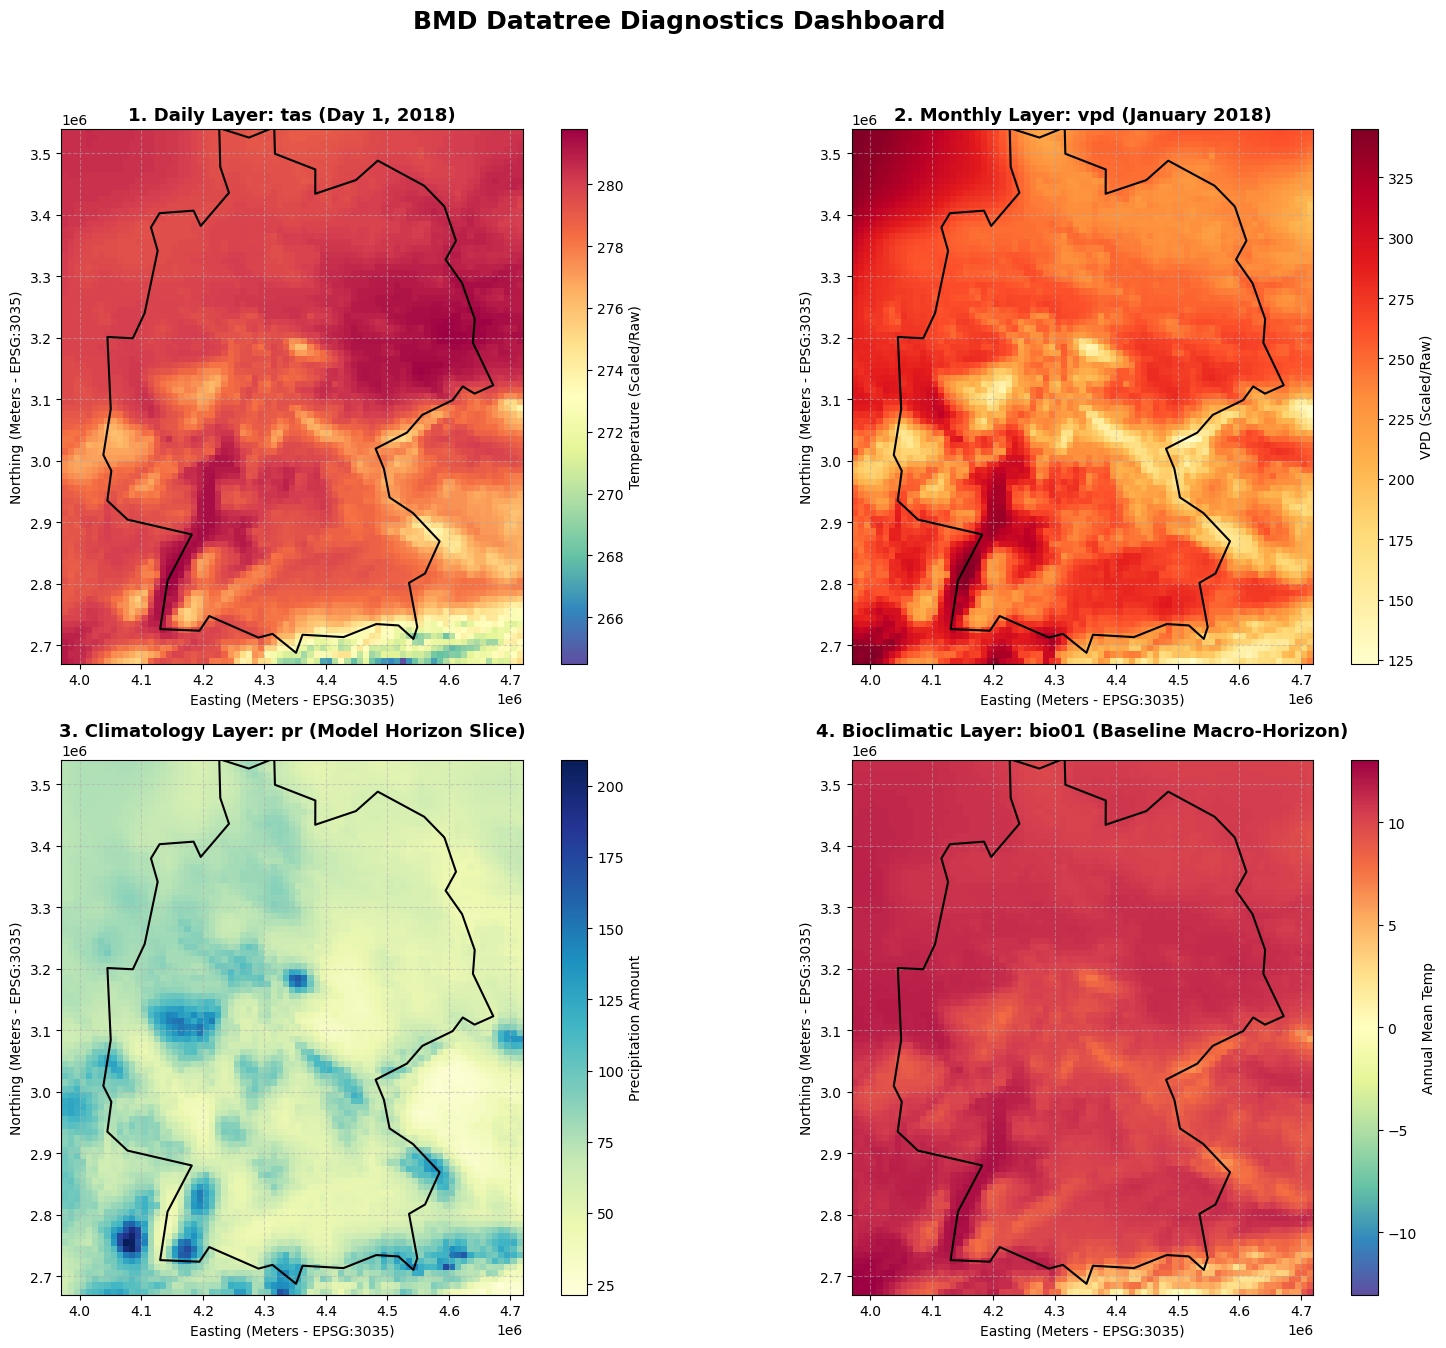

In [8]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
from xarray import open_datatree

# 1. Define paths (Adjust if using a different output path)
cube_path = "./cubing_output/german_chelsa_cube.nc"

if not os.path.exists(cube_path):
    raise FileNotFoundError(f"Could not find the target netCDF cube file at: {cube_path}")

# 2. Load the DataTree
# We load the entire consolidated netCDF tree structure 
dt = open_datatree(cube_path, engine="netcdf4")

# 3. Fetch and reproject Germany's spatial boundary
print("Fetching administrative boundaries for geographic overlay...")
# Fetching a highly stable public Natural Earth country dataset
world_geojson_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(world_geojson_url)

# Isolate Germany and reproject its vector polygon to match your EEA Grid (EPSG:3035)
germany_boundary = world[world['SOVEREIGNT'] == 'Germany'].to_crs("EPSG:3035")

# 4. Set up a 2x2 dashboard layout
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14), sharex=False, sharey=False)
axes = axes.flatten() # Flatten into a 1D array for easier loop indexing

# Set a shared color ramp configuration for clear rendering
cmap_temp = "Spectral_r"
cmap_precip = "YlGnBu"

# =====================================================================
# SUBPLOT 1: Daily Level (Slice: Day 1 Mean Temperature)
# =====================================================================
ax1 = axes[0]
# Use .isel(time=0) to pull the first day of 2018 safely
daily_slice = dt['chelsa/daily'].ds['tas'].isel(time=0)

# Render the raster map
daily_slice.plot(ax=ax1, cmap=cmap_temp, cbar_kwargs={'label': 'Temperature (Scaled/Raw)'})
# Overlay the vector boundary line
germany_boundary.geometry.boundary.plot(ax=ax1, color='black', linewidth=1.5)
ax1.set_title("1. Daily Layer: tas (Day 1, 2018)", fontsize=13, weight='bold')

# =====================================================================
# SUBPLOT 2: Monthly Level (Slice: Month 1 Vapor Pressure Deficit)
# =====================================================================
ax2 = axes[1]
# Use .isel(time=0) to select January 2018
monthly_slice = dt['chelsa/monthly'].ds['vpd'].isel(time=0)

monthly_slice.plot(ax=ax2, cmap="YlOrRd", cbar_kwargs={'label': 'VPD (Scaled/Raw)'})
germany_boundary.geometry.boundary.plot(ax=ax2, color='black', linewidth=1.5)
ax2.set_title("2. Monthly Layer: vpd (January 2018)", fontsize=13, weight='bold')

# =====================================================================
# SUBPLOT 3: Climatologies Level (Slice: First Modeled Matrix)
# =====================================================================
ax3 = axes[2]
# Using .isel(projection=0) is foolproof against both MultiIndex 
# and flattened coordinate configurations. Let's look at precipitation.
climatology_slice = dt['chelsa/climatologies'].ds['pr'].isel(projection=0)

climatology_slice.plot(ax=ax3, cmap=cmap_precip, cbar_kwargs={'label': 'Precipitation Amount'})
germany_boundary.geometry.boundary.plot(ax=ax3, color='black', linewidth=1.5)
ax3.set_title("3. Climatology Layer: pr (Model Horizon Slice)", fontsize=13, weight='bold')

# =====================================================================
# SUBPLOT 4: Bioclimatic Level (Slice: Bio01 - Annual Mean Temperature)
# =====================================================================
ax4 = axes[3]
# Isolate the first element of the projection array for Bio01
bioclim_slice = dt['chelsa/bioclim'].ds['bio01'].isel(projection=0)

bioclim_slice.plot(ax=ax4, cmap=cmap_temp, cbar_kwargs={'label': 'Annual Mean Temp'})
germany_boundary.geometry.boundary.plot(ax=ax4, color='black', linewidth=1.5)
ax4.set_title("4. Bioclimatic Layer: bio01 (Baseline Macro-Horizon)", fontsize=13, weight='bold')

# =====================================================================
# GLOBAL FORMATTING & RENDERING
# =====================================================================
# Clean up axes styling across all panels
for ax in axes:
    ax.set_xlabel("Easting (Meters - EPSG:3035)", fontsize=10)
    ax.set_ylabel("Northing (Meters - EPSG:3035)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle(f"BMD Datatree Diagnostics Dashboard", fontsize=18, weight='bold', y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Display dashboard inside notebook environment
plt.show()